# 0. Generation of the dataset

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
# AdaBoost Algorithm
from sklearn.ensemble import AdaBoostClassifier
# Gradient Boosting 
from sklearn.ensemble import GradientBoostingClassifier
# XGBoost
import xgboost
from xgboost import XGBClassifier
from xgboost import plot_importance, to_graphviz, plot_tree
print("XGBoost version:",xgboost.__version__)

mycmap = "winter"
mpl.rcParams['image.cmap'] = mycmap
plt.rcParams['font.size'] = 13

XGBoost version: 3.2.0


## Read and split data

In [3]:
np.random.seed(12345)

dname="./DATA/"
str0="_XGB_26.dat"
fnamex=dname+'x'+str0
fnamey=dname+'y'+str0
x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
y = np.loadtxt(fnamey)
y = y.astype(int)
N,L = len(x), len(x[0])

N_train = int(0.75*N)
x_train,y_train = x[:N_train],y[:N_train]
x_test,y_test = x[N_train:],y[N_train:]
print(f"N={N}, N_train={N_train}, L={L}")

N=5000, N_train=3750, L=4


### Scatter plot on \[i,j\] feature plane

[-31.608 -29.544   6.773   9.554] 0
[46.451 15.318 24.891 15.357] 0
[ 24.771  46.131 -49.161 -39.356] 0
[-20.13   15.641  30.981  37.218] 0
[46.465 22.369 14.248 21.745] 0


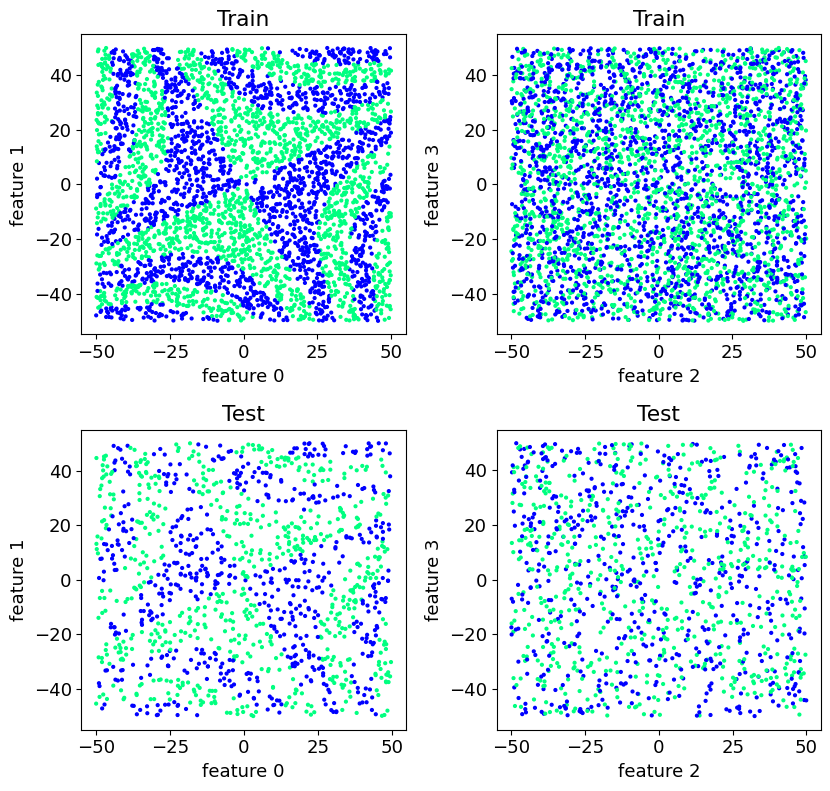

In [4]:
def scat(ax,x,y,i=0,j=1,s=4,title=""):
    # scatter plot of the data in the plane of features i and j
    ax.scatter(x[:,i],x[:,j],s=s,c=y) 
    ax.set_xlabel(f"feature {i}")
    ax.set_ylabel(f"feature {j}")
    ax.set_title(title)

# print the first 5 data points
for n in range(5):
    print(x[n],y[n])

#print feature plots for the training and test sets
fig,AX = plt.subplots(2,2,figsize=(8.5,8.1))
scat(AX[0,0],x_train,y_train,title="Train")
scat(AX[0,1],x_train,y_train,i=2,j=3,title="Train")
scat(AX[1,0],x_test,y_test,title="Test")
scat(AX[1,1],x_test,y_test,i=2,j=3,title="Test")
fig.tight_layout()
plt.show()

In [5]:
# https://machinelearningmastery.com/feature-importance-and-feature-selection-with-xgboost-in-python/
# feature importance

print(model.importance_type)
print(model.feature_importances_)
# plot
my_cmap = plt.get_cmap("Reds")
# rescale the feature importances to the range [0.3,1] for better visualization
rescale = lambda y: 0.3 + 0.7 * (y - np.min(y)) / (np.max(y) - np.min(y))
plt.bar(range(len(model.feature_importances_)), model.feature_importances_,
        color=my_cmap(rescale(model.feature_importances_)))
plt.xlabel("feature")
plt.ylabel("importance")
plt.xticks(np.arange(L))
plt.title(model.importance_type)
plt.show()

rescale_r = lambda y: 0.3 + 0.7 * (np.max(y) - y) / (np.max(y) - np.min(y))
plot_importance(model,color=my_cmap(rescale_r(model.feature_importances_)))
plt.show()

NameError: name 'model' is not defined

In [6]:
def classify(clf=GradientBoostingClassifier()):
    
    clf.fit(x_train,y_train) # train the model on the training set
    y_hat = clf.predict(x_test) # predict the labels of the test set

    #defining accuracy as a global variable
    global accuracy
    accuracy = clf.score(x_test, y_test)
    print("errors: {:.2f}%   Accuracy={:.3f}".format(100*(1-clf.score(x_test, y_test)),clf.score(x_test, y_test)))
    S=50 # size of the square grid
    dx = 1
    x_seq=np.arange(-S,S+dx,dx) # sequence of points for the grid
    nx = len(x_seq)
    x_plot=np.zeros((nx*nx,L)) # grid of points
    print('shape of x_plot=',x_plot.shape)
    q=0
    for i in range(nx):
        for j in range(nx):
            x_plot[q,:2] = [x_seq[i],x_seq[j]] # only the first two features are used for the artificial grid
            q+=1
    y_plot= clf.predict(x_plot) # predict the labels of the grid points

    fig,AX = plt.subplots(1,2,figsize=(8.2,4))
    scat(AX[0],x_plot[:],y_plot,s=dx,title="predicted")
    scat(AX[1],x_train[:],y_train,title="training set")
    fig.tight_layout()
    plt.show()

errors: 6.64%   Accuracy=0.934
shape of x_plot= (10201, 4)


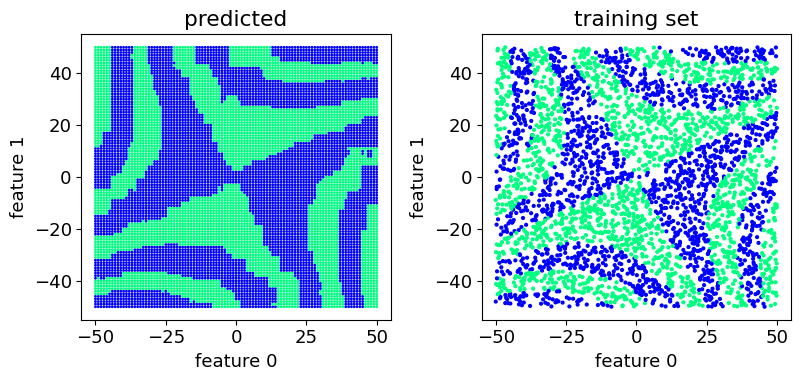

In [7]:
model = XGBClassifier(seed=1,
                      objective='binary:logistic',
                      importance_type="gain") 
classify(model)

# 1. Model complexity, parameters and regularization
In this section we will study the accurcy of the model for different parameters


In [8]:
n_estimators_list  = [50, 100, 200, 400]
max_depth_list     = [2, 3, 5, 7, 10, 15, 20]
learning_rate_list = [0.01, 0.05, 0.1, 0.3, 0.5, 1]
 
results = []
 
for n_est in n_estimators_list:
    for depth in max_depth_list:
        for lr in  learning_rate_list:
            model = XGBClassifier(
                n_estimators=n_est,
                max_depth=depth,
                learning_rate=lr,
                reg_lambda=1.0,
                gamma=0.0,
                eval_metric="logloss",
                random_state=42,
                verbosity=0,
            )
            model.fit(x_train, y_train)
            acc_train = model.score(x_train, y_train)
            acc_val   = model.score(x_test, y_test)
            results.append((n_est, depth, lr, acc_train, acc_val))
         

results.sort(key=lambda r: -r[4])
 
print(f"{'n_est':>6} {'depth':>5} {'lr':>6} | {'train':>7} {'val':>7} {'gap':>7}")
print("-" * 50)
for n_est, depth, lr, acc_tr, acc_va in results:
    print(f"{n_est:>6} {depth:>5} {lr:>6.2f} | {acc_tr:>7.4f} {acc_va:>7.4f} {acc_tr-acc_va:>+7.4f}")


 n_est depth     lr |   train     val     gap
--------------------------------------------------
   200    20   0.10 |  1.0000  0.9408 +0.0592
   100    20   0.30 |  1.0000  0.9400 +0.0600
   400    15   0.05 |  1.0000  0.9400 +0.0600
    50    20   0.30 |  1.0000  0.9392 +0.0608
   100    20   0.10 |  1.0000  0.9392 +0.0608
   400    15   0.10 |  1.0000  0.9384 +0.0616
   400    20   0.10 |  1.0000  0.9384 +0.0616
   100    10   0.30 |  1.0000  0.9376 +0.0624
   200    15   0.05 |  1.0000  0.9376 +0.0624
   200    15   0.10 |  1.0000  0.9376 +0.0624
   200    20   0.30 |  1.0000  0.9376 +0.0624
    50    10   0.30 |  1.0000  0.9368 +0.0632
    50    20   0.10 |  0.9995  0.9368 +0.0627
   400    10   0.10 |  1.0000  0.9368 +0.0632
   400    20   0.05 |  1.0000  0.9368 +0.0632
   100    15   0.30 |  1.0000  0.9360 +0.0640
   200     7   0.10 |  0.9995  0.9360 +0.0635
   200    10   0.10 |  1.0000  0.9360 +0.0640
    50    15   0.30 |  1.0000  0.9352 +0.0648
    50    15   0.50 |  1.0000

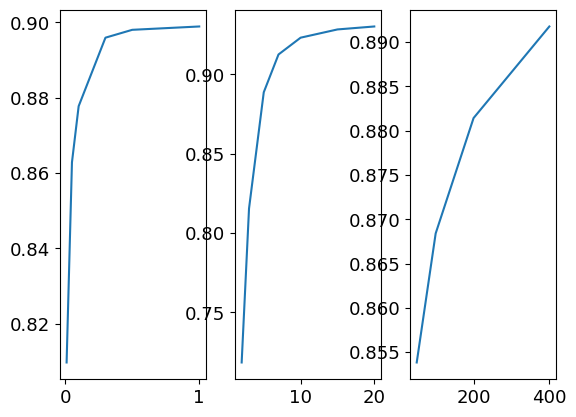

In [9]:
mean_val_vs_lr = []
mean_val_vs_depth = []
mean_val_vs_nest = []
results = np.array(results)

for lr in learning_rate_list:
    mask = results[:,2] == lr
    mean_val_vs_lr.append(np.mean(results[mask, 4]))
    
for depth in max_depth_list:
    mask = results[:,1] == depth
    mean_val_vs_depth.append(np.mean(results[mask, 4]))
    
for n_est in n_estimators_list:
    mask = results[:,0] == n_est
    mean_val_vs_nest.append(np.mean(results[mask, 4]))

fig, axes = plt.subplots(nrows=1,ncols=3)
axes[0].plot(learning_rate_list, mean_val_vs_lr)
axes[1].plot(max_depth_list, mean_val_vs_depth)
axes[2].plot(n_estimators_list, mean_val_vs_nest)


In [10]:
n_estimators_list  = [50, 100, 200, 400, 1000, 2000]
max_depth_list     = [2, 3, 5, 7, 10, 15, 20]
learning_rate_list = [0.01, 0.05, 0.1, 0.3, 0.5, 1]
 
results = []
 
for n_est in n_estimators_list:
    for depth in max_depth_list:
        for lr in  learning_rate_list:
            model = XGBClassifier(
                n_estimators=n_est,
                max_depth=depth,
                learning_rate=lr,
                reg_lambda=1.0,
                gamma=0.0,
                eval_metric="logloss",
                random_state=42,
                verbosity=0,
            )
            model.fit(x_train, y_train)
            acc_train = model.score(x_train, y_train)
            acc_val   = model.score(x_test, y_test)
            results.append((n_est, depth, lr, acc_train, acc_val))

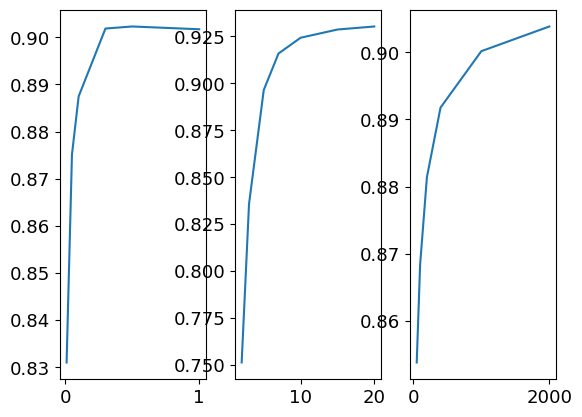

In [11]:
mean_val_vs_lr = []
mean_val_vs_depth = []
mean_val_vs_nest = []
results = np.array(results)

for lr in learning_rate_list:
    mask = results[:,2] == lr
    mean_val_vs_lr.append(np.mean(results[mask, 4]))
    
for depth in max_depth_list:
    mask = results[:,1] == depth
    mean_val_vs_depth.append(np.mean(results[mask, 4]))
    
for n_est in n_estimators_list:
    mask = results[:,0] == n_est
    mean_val_vs_nest.append(np.mean(results[mask, 4]))

fig, axes = plt.subplots(nrows=1,ncols=3)
axes[0].plot(learning_rate_list, mean_val_vs_lr)
axes[1].plot(max_depth_list, mean_val_vs_depth)
axes[2].plot(n_estimators_list, mean_val_vs_nest)


In [12]:
n_estimators  = 400
max_depth     = 15
learning_rate = 0.3
 
results = []
 

model = XGBClassifier(
    seed=1,
    objective='binary:logistic',
    importance_type="gain",
    n_estimators=n_estimators,
    max_depth=max_depth,
    learning_rate=learning_rate,
    reg_lambda=1.0
    
)
model.fit(x_train, y_train)
acc_train = model.score(x_train, y_train)
acc_val   = model.score(x_test, y_test)

print(f"{'n_est':>6} {'depth':>5} {'lr':>6} | {'train':>7} {'val':>7} {'gap':>7}")
print("-" * 50)
print(f"{n_estimators_list:>6} {max_depth_list:>5} {learning_rate_list:>6.2f} | {acc_train:>7.4f} {acc_val:>7.4f} {acc_train-acc_val:>+7.4f}")


 n_est depth     lr |   train     val     gap
--------------------------------------------------


TypeError: unsupported format string passed to list.__format__

0.001	0.9312
0.01	0.9312
0.1	0.9312
0.4	0.9344
0.5	0.9344
0.6	0.9304
0.7	0.928
1	0.9312
3	0.936
7	0.9344
10	0.936
30	0.9296
100	0.928
300	0.9144


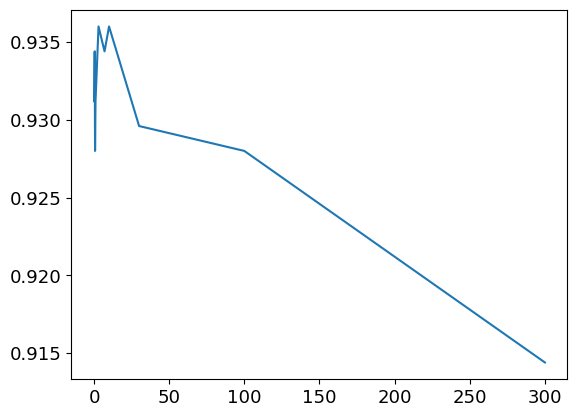

In [13]:
lambda_val_list = [0.001, 0.01, 0.1, 0.4, 0.5, 0.6 ,0.7, 1, 3, 7, 10, 30, 100, 300]
res = []

for l in lambda_val_list:
    model = XGBClassifier(
    seed=1,
    objective='binary:logistic',
    importance_type="gain",
    n_estimators=n_estimators,
    max_depth=max_depth,
    learning_rate=learning_rate,
    reg_lambda=l
    )
    model.fit(x_train, y_train)
    acc_train = model.score(x_train, y_train)
    acc_val   = model.score(x_test, y_test)
    print(l, acc_val, sep="\t")
    res.append(acc_val)

fig, ax = plt.subplots(nrows=1,ncols=1)
ax.plot(lambda_val_list, res)

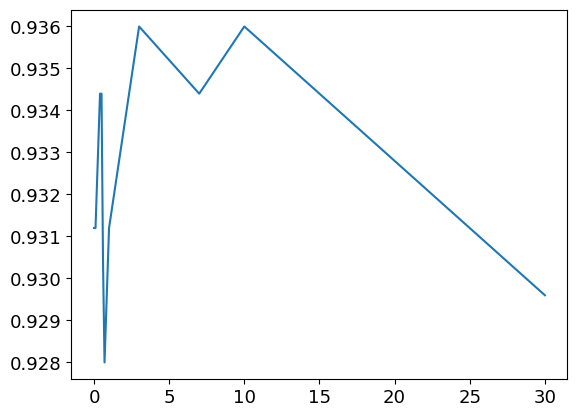

In [14]:
fig, ax = plt.subplots(nrows=1,ncols=1)
ax.plot(lambda_val_list[:-2], res[:-2])

# 2. 

In [15]:
#redefining x_train and x_test without the feauture 3
x_train_012 = x_train[:, :3]
x_test_012 = x_test[:, :3]

In [16]:
#redifining the classification with the new datasets of training and test
def classify_012(clf=GradientBoostingClassifier()):

    clf.fit(x_train_012,y_train) 
    y_hat = clf.predict(x_test_012) 

    global accuracy_012
    accuracy_012 = clf.score(x_test_012, y_test)
    print("errors: {:.2f}%   Accuracy={:.3f}".format(100*(1-clf.score(x_test_012, y_test)),clf.score(x_test_012, y_test)))
    S=50 
    dx = 1
    x_seq=np.arange(-S,S+dx,dx)
    nx = len(x_seq)
    x_plot=np.zeros((nx*nx,L-1))
    print('shape of x_plot=',x_plot.shape)
    q=0
    for i in range(nx):
        for j in range(nx):
            x_plot[q,:2] = [x_seq[i],x_seq[j]] 
            q+=1
    y_plot= clf.predict(x_plot) 

    fig,AX = plt.subplots(1,2,figsize=(8.2,4))
    scat(AX[0],x_plot[:],y_plot,s=dx,title="predicted")
    scat(AX[1],x_train_012[:],y_train,title="training set")
    fig.tight_layout()
    plt.show()

errors: 6.88%   Accuracy=0.931
shape of x_plot= (10201, 3)


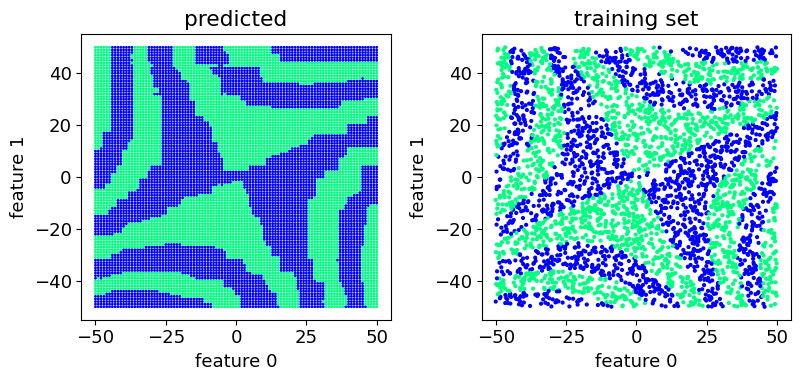

In [17]:
model_012 = XGBClassifier(seed=1,
                      objective='binary:logistic',
                      importance_type="gain") 
classify_012(model_012)

In [18]:
#redefining x_train and x_test without the feauture 3 and 2
x_train_01 = x_train[:, :2]
x_test_01 = x_test[:, :2]

In [19]:
#redifining the classification with the new datasets of training and test
def classify_01(clf=GradientBoostingClassifier()):

    clf.fit(x_train_01,y_train) 
    y_hat = clf.predict(x_test_01) 

    global accuracy_01
    accuracy_01 = clf.score(x_test_01, y_test)
    print("errors: {:.2f}%   Accuracy={:.3f}".format(100*(1-clf.score(x_test_01, y_test)),clf.score(x_test_01, y_test)))
    S=50 
    dx = 1
    x_seq=np.arange(-S,S+dx,dx)
    nx = len(x_seq)
    x_plot=np.zeros((nx*nx,L-2))
    print('shape of x_plot=',x_plot.shape)
    q=0
    for i in range(nx):
        for j in range(nx):
            x_plot[q,:2] = [x_seq[i],x_seq[j]] 
            q+=1
    y_plot= clf.predict(x_plot) 

    fig,AX = plt.subplots(1,2,figsize=(8.2,4))
    scat(AX[0],x_plot[:],y_plot,s=dx,title="predicted")
    scat(AX[1],x_train_01[:],y_train,title="training set")
    fig.tight_layout()
    plt.show()

errors: 6.24%   Accuracy=0.938
shape of x_plot= (10201, 2)


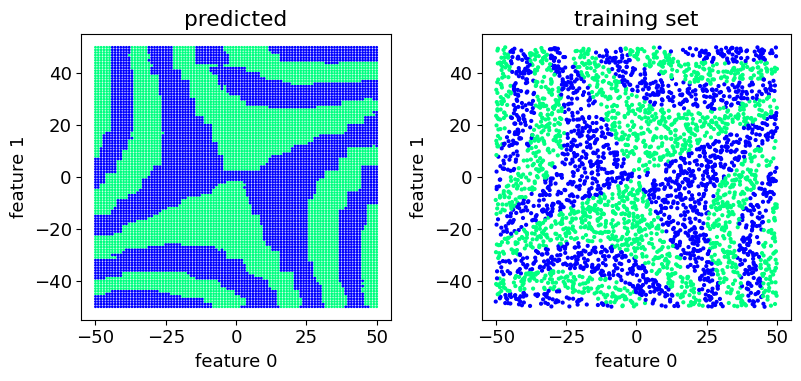

In [20]:
model_01 = XGBClassifier(seed=1,
                      objective='binary:logistic',
                      importance_type="gain") 
classify_01(model_01)

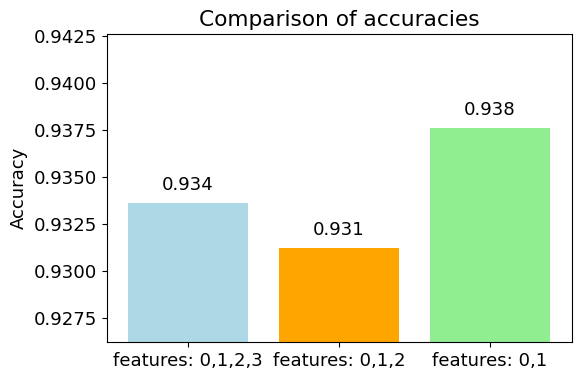

In [21]:
plt.figure(figsize=(6,4))
accuracies = [accuracy, accuracy_012, accuracy_01]
labels = ['features: 0,1,2,3', 'features: 0,1,2', 'features: 0,1']
bars = plt.bar(labels, accuracies, color=['lightblue','orange','lightgreen'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.0005, f"{yval:.3f}", ha='center', va='bottom')


plt.ylim(min(accuracies)-0.005, max(accuracies)+0.005) 
plt.ylabel("Accuracy")
plt.title("Comparison of accuracies")
plt.show()

## Comment on accuracies
As we can see from the plot the accuracy using only feautures 0 and 1 is higher than the others, that's because feutures 2 and 3 are not informative about the dataset. Removing only the third feature doesn't improve the accuracy because of the stochastic process introduced by feature 2. 

## Point 3

We compare our XGB model with only 0,1 features against the generic FFNN out assignment 1, without tuning, to see their performance.

N'=250: XGB1=0.552±0.071 | XGB2=0.552±0.071 | FFNN=0.484±0.056
N'=500: XGB1=0.674±0.066 | XGB2=0.674±0.066 | FFNN=0.530±0.023
N'=1000: XGB1=0.828±0.013 | XGB2=0.828±0.013 | FFNN=0.505±0.022
N'=1500: XGB1=0.856±0.028 | XGB2=0.856±0.028 | FFNN=0.531±0.028
N'=2500: XGB1=0.910±0.014 | XGB2=0.910±0.014 | FFNN=0.530±0.012
N'=3500: XGB1=0.926±0.011 | XGB2=0.926±0.011 | FFNN=0.522±0.032
N'=4500: XGB1=0.932±0.012 | XGB2=0.932±0.012 | FFNN=0.564±0.020


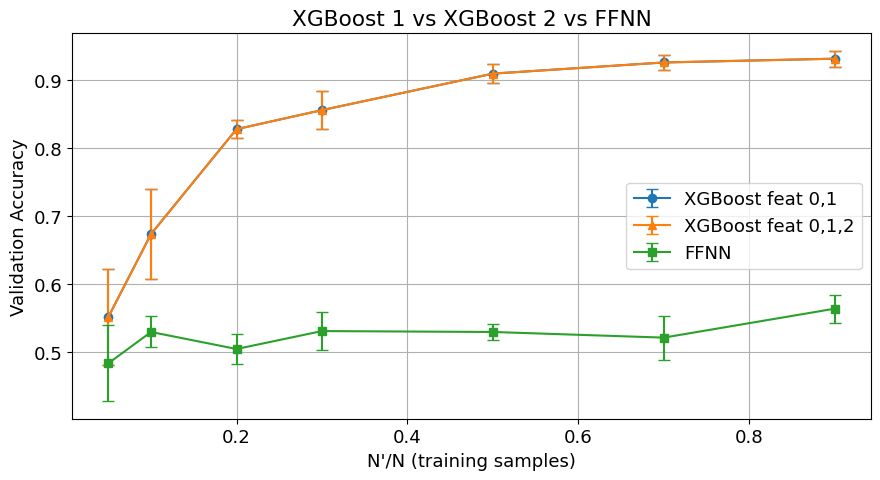

In [23]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.pipeline import Pipeline
from scikeras.wrappers import KerasClassifier
from keras.models import Sequential
from keras.layers import Dense, Dropout

def build_ffnn(L):
    model = keras.Sequential([
        layers.Input(shape=(L,)),
        layers.Dense(20, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(20, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(20, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

fraction = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_xgb1, std_xgb1 = [], []
acc_xgb2, std_xgb2 = [], []
acc_ffnn,  std_ffnn  = [], []

for frac in fraction:
    N_prime = int(N * frac)
    idx = np.random.choice(N, N_prime, replace=False)
    X_sub = x[idx]
    y_sub = y[idx]

    # --- XGBoost 1 ---
    scores1 = cross_val_score(model_01, X_sub, y_sub, cv=kf, scoring='accuracy')
    acc_xgb1.append(scores1.mean())
    std_xgb1.append(scores1.std())

    # --- XGBoost 2 ---
    scores2 = cross_val_score(model_012, X_sub, y_sub, cv=kf, scoring='accuracy')
    acc_xgb2.append(scores2.mean())
    std_xgb2.append(scores2.std())

    # --- FFNN ---
    fold_scores_ffnn = []
    for train_idx, val_idx in kf.split(X_sub, y_sub):
        X_train, X_val = X_sub[train_idx], X_sub[val_idx]
        y_train, y_val = y_sub[train_idx], y_sub[val_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val   = scaler.transform(X_val)

        model = build_ffnn(L)
        model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

        _, acc = model.evaluate(X_val, y_val, verbose=0)
        fold_scores_ffnn.append(acc)

    acc_ffnn.append(np.mean(fold_scores_ffnn))
    std_ffnn.append(np.std(fold_scores_ffnn))

    print(f"N'={N_prime}: "
          f"XGB1={acc_xgb1[-1]:.3f}±{std_xgb1[-1]:.3f} | "
          f"XGB2={acc_xgb2[-1]:.3f}±{std_xgb2[-1]:.3f} | "
          f"FFNN={acc_ffnn[-1]:.3f}±{std_ffnn[-1]:.3f}")

# --- Plot ---
N_primes = [int(N * f) for f in fraction]

plt.figure(figsize=(9, 5))
plt.errorbar(fraction, acc_xgb1, yerr=std_xgb1, marker='o', capsize=4, label='XGBoost feat 0,1')
plt.errorbar(fraction, acc_xgb2, yerr=std_xgb2, marker='^', capsize=4, label='XGBoost feat 0,1,2')
plt.errorbar(fraction, acc_ffnn,  yerr=std_ffnn,  marker='s', capsize=4, label='FFNN')
plt.xlabel("N'/N (training samples)")
plt.ylabel("Validation Accuracy")
plt.title("XGBoost 1 vs XGBoost 2 vs FFNN")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

We can see that with N' small, XGB with 2 and 3 features has a better perfomance with respect to the FFNN, as we expect. The surprising part is that even for N'/N close to 1 the accuracy of the FFNN isn't improving. To improve the perfomance of the FFNN, we could try to tune it, but for now we stick to use k-fold cross validation to improve the perfomance.

In [38]:
"""
Trying k-cross validation but i don't know why it doesn't work

def build_model(hp):
    model = Sequential([
        Input(shape=(L,)),
        Dense(L, activation='relu'),
    ])

    # Hyperparameters
    dropout_rate  = hp.Float("dropout_rate", min_value=0.0, max_value=0.4, step=0.1)
    activation    = hp.Choice("activation", values=["relu", "elu"])
    learning_rate = hp.Float("learning_rate", min_value=1e-6, max_value=1e-1, sampling="log")
    optimizer_name = hp.Choice("optimizer", values=["adam", "sgd", "rmsprop", "nadam"])

    # Inner layers
    for _ in range(3):
        model.add(Dense(20, activation=activation))
        model.add(Dropout(dropout_rate))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Optimizer
    optimizers = {
        "adam":    keras.optimizers.Adam(learning_rate=learning_rate),
        "sgd":     keras.optimizers.SGD(learning_rate=learning_rate),
        "rmsprop": keras.optimizers.RMSprop(learning_rate=learning_rate),
        "nadam":   keras.optimizers.Nadam(learning_rate=learning_rate),
    }

    model.compile(
        optimizer=optimizers[optimizer_name],
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model
"""

In [41]:
"""
outer_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

acc_xgb, std_xgb = [], []
acc_ffnn_tuned, std_ffnn_tuned = [], []

for frac in fraction:
    N_prime = int(N * frac)
    idx = np.random.choice(N, N_prime, replace=False)
    X_sub, y_sub = x[idx], y[idx]
    
    # --- XGBoost (outer CV semplice) ---
    scores_xgb = cross_val_score(model_01, X_sub, y_sub,
                                  cv=outer_kf, scoring='accuracy')
    acc_xgb.append(scores_xgb.mean())
    std_xgb.append(scores_xgb.std())
    
    # --- FFNN con tuning (nested CV) ---
    fold_scores = []


    for fold, (train_idx, val_idx) in enumerate(outer_kf.split(X_sub, y_sub)):
        X_tr, X_val = X_sub[train_idx], X_sub[val_idx]
        y_tr, y_val = y_sub[train_idx], y_sub[val_idx]
    
        scaler = StandardScaler()
        X_tr  = scaler.fit_transform(X_tr)
        X_val = scaler.transform(X_val)
    
        X_inner_tr, X_inner_val, y_inner_tr, y_inner_val = train_test_split(
            X_tr, y_tr, test_size=0.2, stratify=y_tr, random_state=42
        )
    
        tuner = kt.RandomSearch(
            build_model,                          
            objective='val_accuracy',
            max_trials=15,
            executions_per_trial=1,
            directory=f'tuner_frac{frac}_fold{fold}',
            project_name='ffnn_search',
            overwrite=True
        )
    
        tuner.search(
            X_inner_tr, y_inner_tr,
            validation_data=(X_inner_val, y_inner_val),
            epochs=50,
            batch_size=32,
            callbacks=[keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5)],
            verbose=0
        )
    
        # Riaddestra il miglior modello su tutto il fold di training
        best_hp = tuner.get_best_hyperparameters(1)[0]
        best_model = build_model(best_hp)
        best_model.fit(X_tr, y_tr, epochs=80, batch_size=32, verbose=0)
    
        _, acc = best_model.evaluate(X_val, y_val, verbose=0)
        fold_scores.append(acc)
        
    acc_ffnn_tuned.append(np.mean(fold_scores))
    std_ffnn_tuned.append(np.std(fold_scores))
    
    print(f"N'={N_prime}: XGB={acc_xgb[-1]:.3f}±{std_xgb[-1]:.3f} | "
              f"FFNN tuned={acc_ffnn_tuned[-1]:.3f}±{std_ffnn_tuned[-1]:.3f}")




N_primes = [int(N * f) for f in frazioni]

plt.figure(figsize=(9, 5))
plt.errorbar(N_primes, acc_xgb, yerr=std_xgb,
             marker='o', label='XGBoost', capsize=4)
plt.errorbar(N_primes, acc_ffnn_tuned, yerr=std_ffnn_tuned,
             marker='s', label='FFNN (tuned)', capsize=4, linestyle='--')
plt.xlabel("N' (training samples)")
plt.ylabel("Validation Accuracy")
plt.title("XGBoost vs FFNN tuned — nested CV")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
"""

NameError: name 'train_test_split' is not defined